In [5]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [6]:
#Data Loading
trades = pd.read_csv(r'C:/Users/shrey/OneDrive/Desktop/finance/historical_data.csv')
sentiment = pd.read_csv(r'C:/Users/shrey/OneDrive/Desktop/finance/fear_greed_index.csv')

In [7]:
#Data Inspection
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

print(trades.head())
print(sentiment.head())

print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Tr

In [8]:
#Data Cleaning
# Clean column names
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert timestamps
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')

# Drop invalid rows
trades = trades.dropna(subset=['timestamp_ist']).copy()

# Create date column
trades['date'] = trades['timestamp_ist'].dt.normalize()

# Fix sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [9]:
#Data Merging
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

# Remove unmatched rows
df = df.dropna(subset=['classification'])

print("Final dataset size:", df.shape)

Final dataset size: (35864, 18)


In [10]:
#Feature Engineering
# Profit flag
df['win'] = df['closed_pnl'] > 0

# Long/Short indicator
df['is_long'] = df['side'] == 'BUY'

In [11]:
#Performance vs Sentiment
df.groupby('classification')['closed_pnl'].mean()
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64

In [12]:
#Behavior Analysis
df.groupby('classification')['size_usd'].mean()
df.groupby('classification').size()

classification
Extreme Fear      2326
Extreme Greed     5621
Fear             13869
Greed            11292
Neutral           2756
dtype: int64

In [13]:
#Segmentation
# High vs Low traders
df['size_category'] = df['size_usd'].apply(
    lambda x: 'High' if x > df['size_usd'].median() else 'Low'
)

df.groupby(['size_category', 'classification'])['closed_pnl'].mean()

size_category  classification
High           Extreme Fear        2.545082
               Extreme Greed     476.756731
               Fear              232.916465
               Greed              97.891493
               Neutral            58.886549
Low            Extreme Fear        1.237058
               Extreme Greed      22.007281
               Fear                5.365442
               Greed               6.625255
               Neutral             4.522661
Name: closed_pnl, dtype: float64

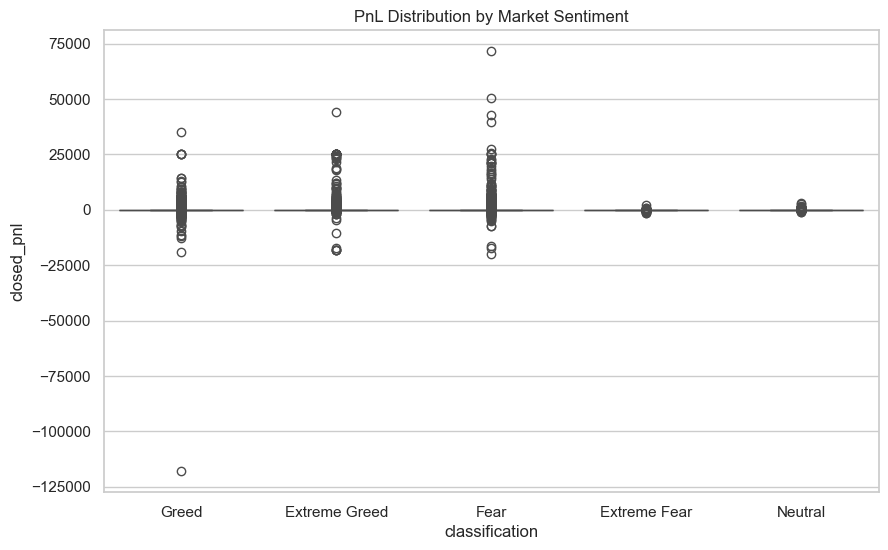

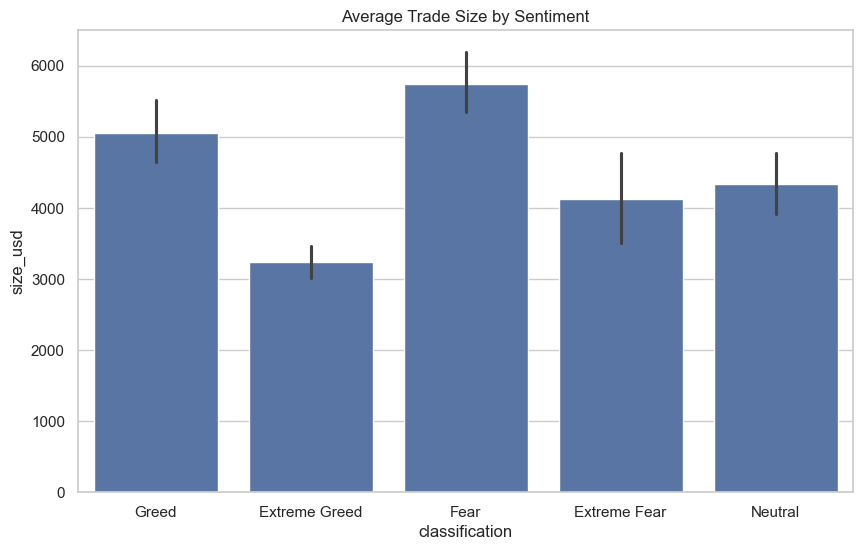

In [14]:
#Visualization
# PnL Distribution
plt.figure(figsize=(10,6))
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

# Trade Size
plt.figure(figsize=(10,6))
sns.barplot(x='classification', y='size_usd', data=df)
plt.title("Average Trade Size by Sentiment")
plt.show()

In [15]:
#Predictive Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Encode sentiment
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes

features = df[['size_usd', 'sentiment_encoded']]
target = df['win']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Feature importance
importance = pd.Series(model.feature_importances_, index=features.columns)
print(importance)

Accuracy: 0.6326502160881082
size_usd             0.974906
sentiment_encoded    0.025094
dtype: float64


In [16]:
# Check how many failed
print(trades['timestamp_ist'].isnull().sum())

# Drop invalid rows
trades = trades.dropna(subset=['timestamp_ist'])

0


In [17]:
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date'],
      dtype='object')


In [18]:
#Win Rate
df['win'] = df['closed_pnl'] > 0
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64

In [19]:
#Trades per day
df.groupby('date').size()

date
2023-01-05       3
2023-05-12       9
2024-01-01      18
2024-01-02       6
2024-01-03     137
              ... 
2025-04-02    2512
2025-04-03    2402
2025-04-04    1272
2025-05-01     239
2025-05-02    1297
Length: 158, dtype: int64

In [20]:
#Long/Short Ratio
df['is_long'] = df['side'] == 'BUY'
df.groupby('classification')['is_long'].mean()

classification
Extreme Fear     0.502150
Extreme Greed    0.295499
Fear             0.526858
Greed            0.478835
Neutral          0.370102
Name: is_long, dtype: float64

In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6326502160881082
              precision    recall  f1-score   support

       False       0.68      0.68      0.68      4087
        True       0.57      0.57      0.57      3086

    accuracy                           0.63      7173
   macro avg       0.63      0.62      0.62      7173
weighted avg       0.63      0.63      0.63      7173



In [22]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features.columns)
print(importance.sort_values(ascending=False))

size_usd             0.974906
sentiment_encoded    0.025094
dtype: float64


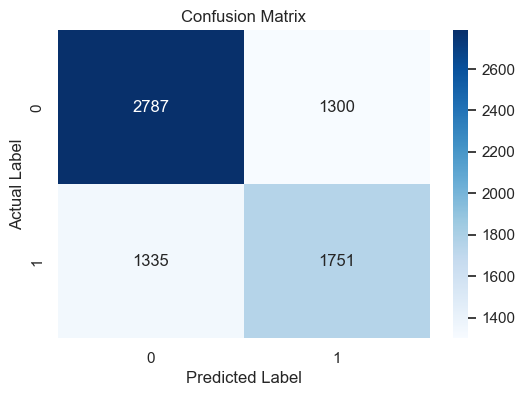

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

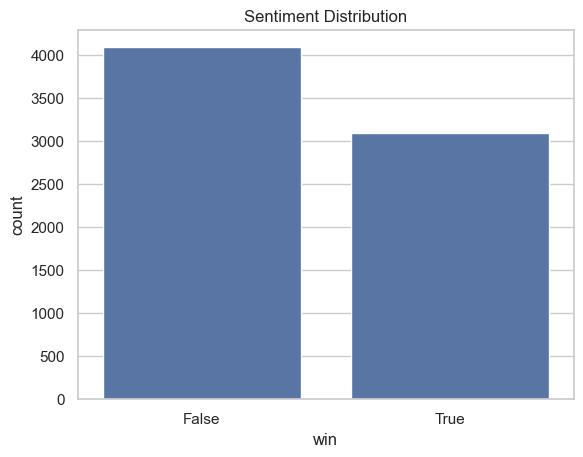

In [25]:
import seaborn as sns

sns.countplot(x=y_test)
plt.title("Sentiment Distribution")
plt.show()

In [27]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
print(df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification', 'win', 'is_long',
       'size_category', 'sentiment_encoded'],
      dtype='object')


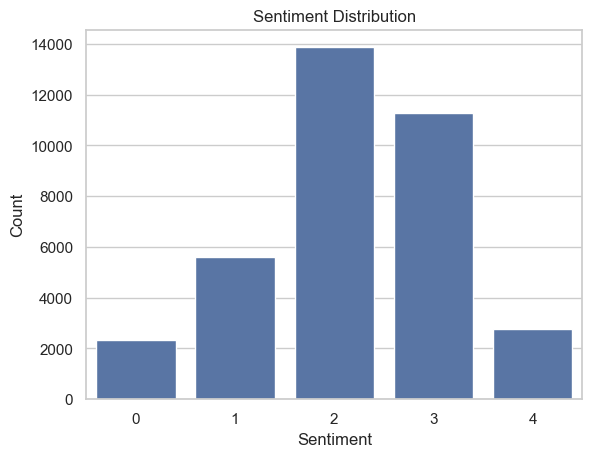

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment_encoded', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

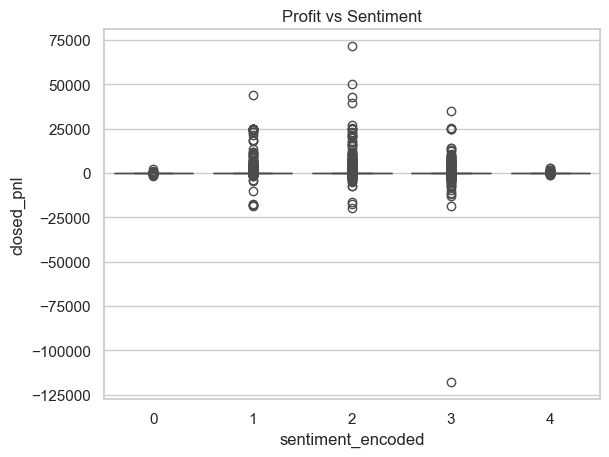

In [32]:
sns.boxplot(x='sentiment_encoded', y='closed_pnl', data=df)
plt.title("Profit vs Sentiment")
plt.show()

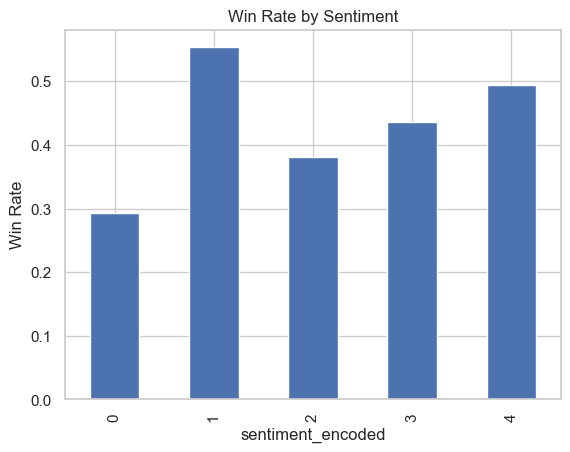

In [33]:
df.groupby('sentiment_encoded')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_9852\2485115825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_encoded', data=df, palette='coolwarm')


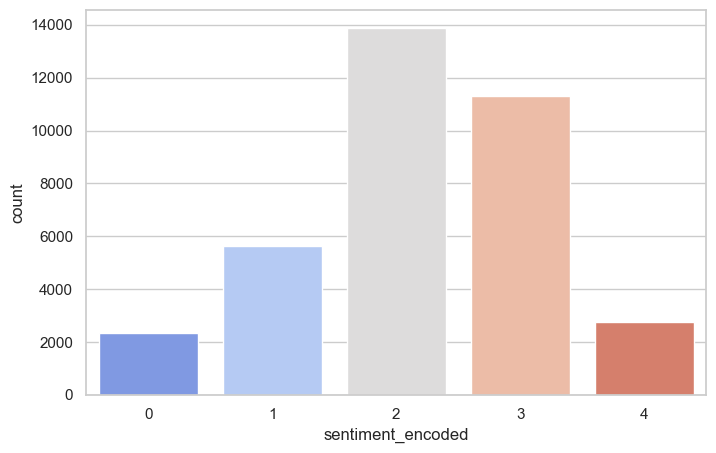

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment_encoded', data=df, palette='coolwarm')
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_9852\3864534821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


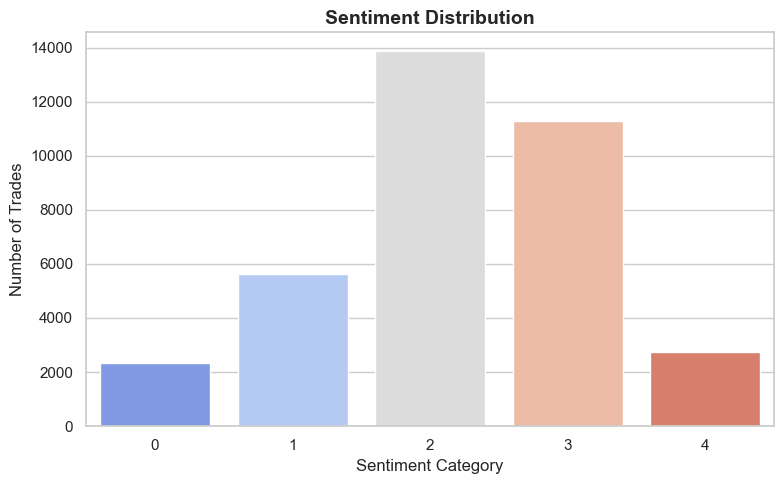

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment_encoded',
    data=df,
    palette='coolwarm'
)

plt.title("Sentiment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.show()

In [37]:
df['sentiment_label'] = df['sentiment_encoded'].map({
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive"
})

<Axes: xlabel='sentiment_label', ylabel='count'>

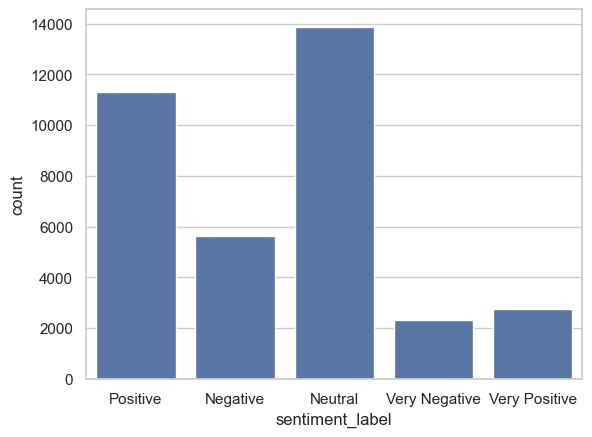

In [38]:
sns.countplot(x='sentiment_label', data=df)